In [3]:
import os
import random
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms
from torchvision.transforms import InterpolationMode

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [8]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8
    num_workers = 2
    pin_memory = torch.cuda.is_available()

    in_channels = 3
    out_channels = 1
    base_channels = 32
    use_batchnorm = False

config = Config()
print(config)

Config()


In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, use_batchnorm=False):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm),
            nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm),
            nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity(),
            nn.ReLU(inplace=True),
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


In [10]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=32, use_batchnorm=False):
        super(UNet, self).__init__()

        self.enc1 = DoubleConv(in_channels, base_channels, use_batchnorm)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(base_channels, base_channels * 2, use_batchnorm)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4, use_batchnorm)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(base_channels * 4, base_channels * 8, use_batchnorm)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16, use_batchnorm)

        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_channels * 16, base_channels * 8, use_batchnorm)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4, use_batchnorm)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2, use_batchnorm)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels, use_batchnorm)

        self.final_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        s3 = self.enc3(self.pool2(s2))
        s4 = self.enc4(self.pool3(s3))

        bottleneck = self.bottleneck(self.pool4(s4))

        x = self.up4(bottleneck)
        x = torch.cat([x, s4], dim=1)
        x = self.dec4(x)

        x = self.up3(x)
        x = torch.cat([x, s3], dim=1)
        x = self.dec3(x)

        x = self.up2(x)
        x = torch.cat([x, s2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, s1], dim=1)
        x = self.dec1(x)

        return self.final_conv(x)

In [11]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None, image_size=(128, 128)):
        self.root = root
        self.transform = transform
        self.image_size = image_size
        self.dataset = torchvision.datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = F.resize(mask, size=self.image_size, interpolation=InterpolationMode.NEAREST)
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [12]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

        self.model = UNet(
            in_channels=config.in_channels,
            out_channels=config.out_channels,
            base_channels=config.base_channels,
            use_batchnorm=config.use_batchnorm,
        ).to(config.device)

        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform, image_size=self.config.image_size)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        generator = torch.Generator().manual_seed(42)
        train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform, image_size=self.config.image_size)

        self.train_dataloader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
        )
        self.val_dataloader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
        )
        self.test_dataloader = DataLoader(
            self.test_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.num_workers,
            pin_memory=self.config.pin_memory,
        )

    def run(self):
        history = {
            "train_loss": [],
            "val_loss": [],
            "val_iou": [],
            "val_f1": [],
        }

        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["val_iou"].append(val_iou)
            history["val_f1"].append(val_f1)

            print(
                f"Epoch {epoch + 1} / {self.config.epochs}, "
                f"Train Loss: {train_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val IoU: {val_iou:.4f}, "
                f"Val F1-score: {val_f1:.4f}"
            )

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(
            f"Test Loss: {test_loss:.4f}, "
            f"Test IoU: {test_iou:.4f}, "
            f"Test F1-score: {test_f1:.4f}"
        )

        history["test_loss"] = test_loss
        history["test_iou"] = test_iou
        history["test_f1"] = test_f1
        return history

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).squeeze(1).cpu().numpy() > 0.5).astype(np.uint8)
                masks_np = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary', zero_division=0))
                    f1_scores.append(f1_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary', zero_division=0))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).squeeze(1).cpu().numpy() > 0.5).astype(np.uint8)
                masks_np = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary', zero_division=0))
                    f1_scores.append(f1_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary', zero_division=0))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                image_to_show = img.permute(1, 2, 0).cpu().numpy()
                image_to_show = np.clip((image_to_show * 0.5) + 0.5, 0, 1)

                axes[i, 0].imshow(image_to_show)
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

                for j in range(3):
                    axes[i, j].axis("off")

            plt.tight_layout()
            plt.show()

In [13]:
def plot_history(history, title="Training history"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    plt.plot(epochs, history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["val_iou"], label="val IoU")
    plt.plot(epochs, history["val_f1"], label="val F1")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title(title + " - metrics")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

100%|██████████| 792M/792M [00:03<00:00, 234MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 121MB/s] 
100%|██████████| 23/23 [00:08<00:00,  2.75it/s]


Epoch 1 / 10, Train Loss: 0.5545, Val Loss: 0.4561, Val IoU: 0.7513, Val F1-score: 0.8505


100%|██████████| 23/23 [00:08<00:00,  2.66it/s]


Epoch 2 / 10, Train Loss: 0.4431, Val Loss: 0.4173, Val IoU: 0.7616, Val F1-score: 0.8590


100%|██████████| 23/23 [00:08<00:00,  2.69it/s]


...

Epoch 9 / 10, Train Loss: 0.2940, Val Loss: 0.2823, Val IoU: 0.8330, Val F1-score: 0.9042


100%|██████████| 23/23 [00:07<00:00,  2.97it/s]


Epoch 10 / 10, Train Loss: 0.2726, Val Loss: 0.2703, Val IoU: 0.8438, Val F1-score: 0.9102
Testing...


100%|██████████| 115/115 [00:41<00:00,  2.78it/s]

Test Loss: 0.2701, Test IoU: 0.8412, Test F1-score: 0.9075


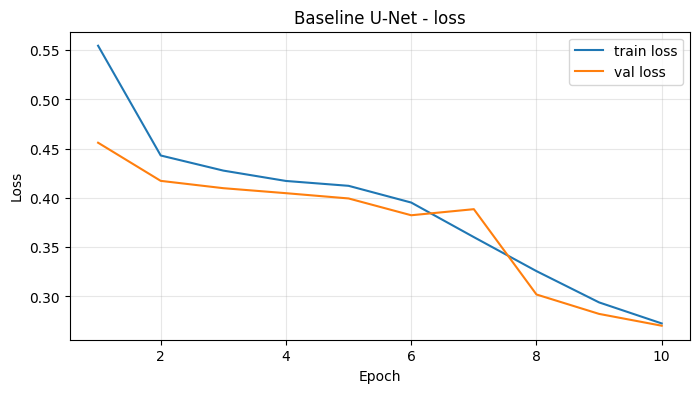

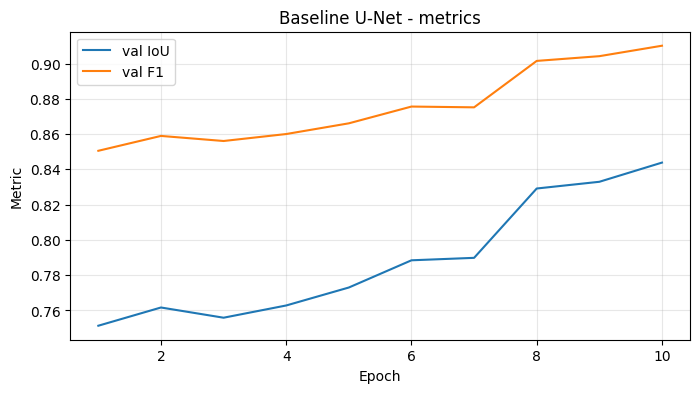

In [15]:
baseline_config = Config()
baseline_config.epochs = 10
baseline_config.learning_rate = 1e-3
baseline_config.batch_size = 32
baseline_config.base_channels = 32
baseline_config.use_batchnorm = False

baseline_trainer = Trainer(baseline_config)
baseline_history = baseline_trainer.run()
plot_history(baseline_history, title="Baseline U-Net")

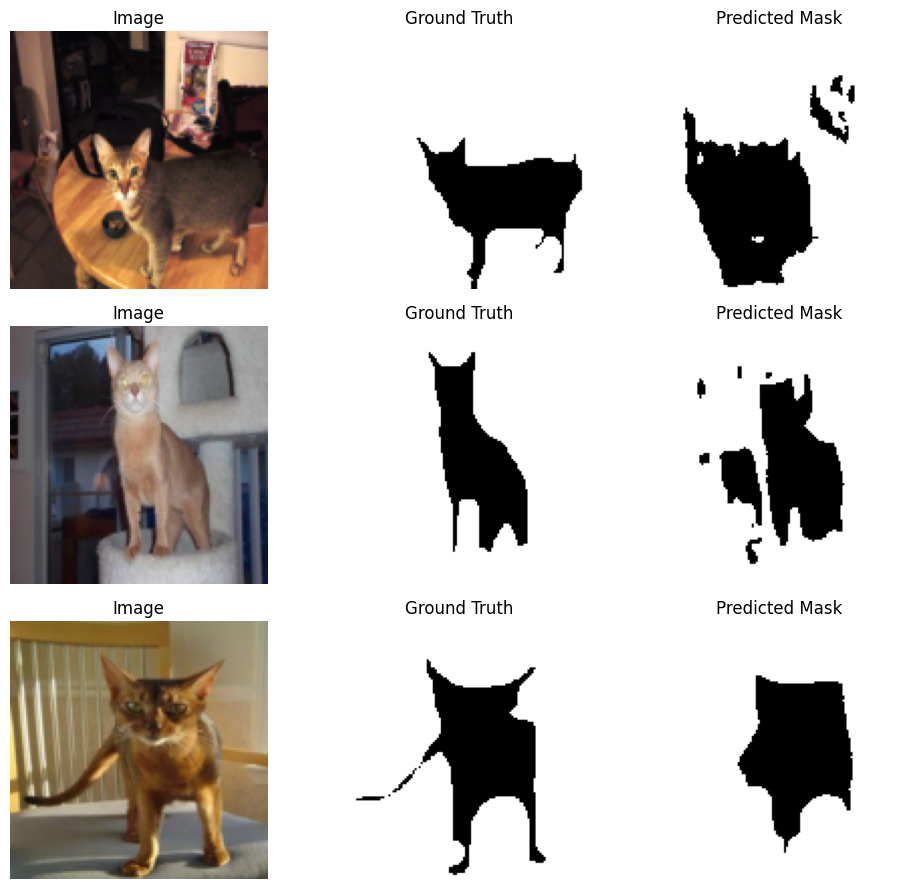

In [16]:
baseline_trainer.inference_and_plot_samples(n_samples=3)

In [17]:
def run_single_experiment(**kwargs):
    exp_config = Config()
    for key, value in kwargs.items():
        setattr(exp_config, key, value)

    trainer = Trainer(exp_config)
    history = trainer.run()

    result = {
        "learning_rate": exp_config.learning_rate,
        "batch_size": exp_config.batch_size,
        "use_batchnorm": exp_config.use_batchnorm,
        "base_channels": exp_config.base_channels,
        "best_val_iou": float(np.max(history["val_iou"])),
        "best_val_f1": float(np.max(history["val_f1"])),
        "final_test_iou": float(history["test_iou"]),
        "final_test_f1": float(history["test_f1"]),
        "history": history,
        "trainer": trainer,
    }
    return result

In [18]:
search_epochs = 4
learning_rates = [1e-3, 3e-4, 1e-4]
batch_sizes = [16, 32, 64]

search_results = []

for lr in learning_rates:
    for batch_size in batch_sizes:
        print("=" * 80)
        print(f"Experiment: lr={lr}, batch_size={batch_size}")
        result = run_single_experiment(
            epochs=search_epochs,
            learning_rate=lr,
            batch_size=batch_size,
            base_channels=32,
            use_batchnorm=False,
        )
        search_results.append(result)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Experiment: lr=0.001, batch_size=16


100%|██████████| 46/46 [00:08<00:00,  5.26it/s]


Epoch 1 / 4, Train Loss: 0.5203, Val Loss: 0.4330, Val IoU: 0.7531, Val F1-score: 0.8538


100%|██████████| 46/46 [00:08<00:00,  5.36it/s]


...

Epoch 3 / 4, Train Loss: 0.5016, Val Loss: 0.4823, Val IoU: 0.7485, Val F1-score: 0.8495


100%|██████████| 12/12 [00:07<00:00,  1.51it/s]


Epoch 4 / 4, Train Loss: 0.4773, Val Loss: 0.4566, Val IoU: 0.7543, Val F1-score: 0.8531
Testing...


100%|██████████| 58/58 [00:40<00:00,  1.44it/s]

Test Loss: 0.4614, Test IoU: 0.7461, Test F1-score: 0.8457


In [19]:
import pandas as pd

results_df = pd.DataFrame(
    [
        {
            "learning_rate": r["learning_rate"],
            "batch_size": r["batch_size"],
            "best_val_iou": r["best_val_iou"],
            "best_val_f1": r["best_val_f1"],
            "final_test_iou": r["final_test_iou"],
            "final_test_f1": r["final_test_f1"],
        }
        for r in search_results
    ]
).sort_values(["best_val_iou", "best_val_f1"], ascending=False)

results_df

,learning_rate,batch_size,best_val_iou,best_val_f1,final_test_iou,final_test_f1
6,0.0001,16,0.771890,0.865863,0.770007,0.862892
1,0.0010,32,0.768381,0.863333,0.764817,0.859466
3,0.0003,16,0.767472,0.860956,0.763601,0.856677
2,0.0010,64,0.762806,0.858354,0.759628,0.854471
0,0.0010,16,0.762253,0.858679,0.751004,0.851024
4,0.0003,32,0.757651,0.853697,0.754417,0.849542
5,0.0003,64,0.756888,0.856421,0.751166,0.850963
8,0.0001,64,0.754278,0.853060,0.746071,0.845735
7,0.0001,32,0.748773,0.851506,0.744227,0.847055


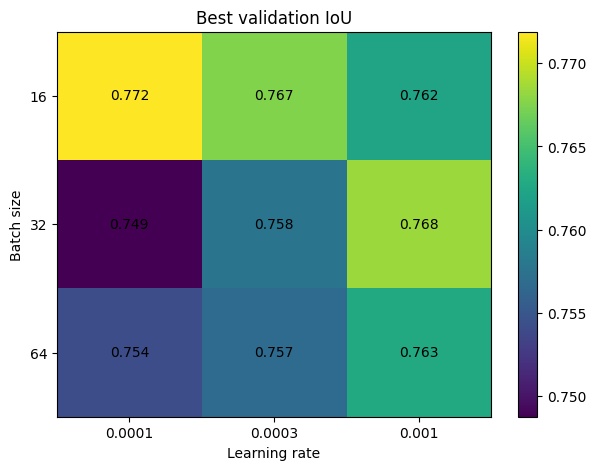

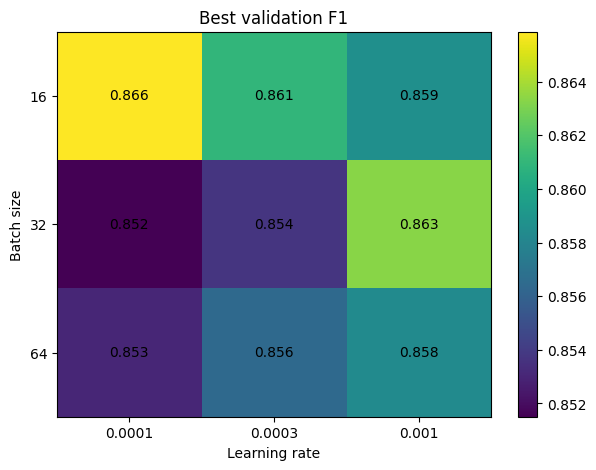

In [20]:
pivot_iou = results_df.pivot(index="batch_size", columns="learning_rate", values="best_val_iou")
pivot_f1 = results_df.pivot(index="batch_size", columns="learning_rate", values="best_val_f1")

plt.figure(figsize=(7, 5))
plt.imshow(pivot_iou.values, aspect="auto")
plt.xticks(range(len(pivot_iou.columns)), [str(c) for c in pivot_iou.columns])
plt.yticks(range(len(pivot_iou.index)), [str(i) for i in pivot_iou.index])
plt.xlabel("Learning rate")
plt.ylabel("Batch size")
plt.title("Best validation IoU")
for i in range(pivot_iou.shape[0]):
    for j in range(pivot_iou.shape[1]):
        plt.text(j, i, f"{pivot_iou.values[i, j]:.3f}", ha="center", va="center")
plt.colorbar()
plt.show()

plt.figure(figsize=(7, 5))
plt.imshow(pivot_f1.values, aspect="auto")
plt.xticks(range(len(pivot_f1.columns)), [str(c) for c in pivot_f1.columns])
plt.yticks(range(len(pivot_f1.index)), [str(i) for i in pivot_f1.index])
plt.xlabel("Learning rate")
plt.ylabel("Batch size")
plt.title("Best validation F1")
for i in range(pivot_f1.shape[0]):
    for j in range(pivot_f1.shape[1]):
        plt.text(j, i, f"{pivot_f1.values[i, j]:.3f}", ha="center", va="center")
plt.colorbar()
plt.show()

In [21]:
best_row = results_df.iloc[0]
best_lr = float(best_row["learning_rate"])
best_batch_size = int(best_row["batch_size"])

print(f"Best hyperparameters: lr={best_lr}, batch_size={best_batch_size}")

Best hyperparameters: lr=0.0001, batch_size=16


In [22]:
best_baseline_result = run_single_experiment(
    epochs=8,
    learning_rate=best_lr,
    batch_size=best_batch_size,
    base_channels=32,
    use_batchnorm=False,
)

modified_result = run_single_experiment(
    epochs=8,
    learning_rate=best_lr,
    batch_size=best_batch_size,
    base_channels=32,
    use_batchnorm=True,
)

print("Baseline test IoU:", best_baseline_result["final_test_iou"])
print("Modified U-Net test IoU:", modified_result["final_test_iou"])

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:08<00:00,  5.65it/s]


Epoch 1 / 8, Train Loss: 0.5534, Val Loss: 0.4763, Val IoU: 0.7443, Val F1-score: 0.8475


100%|██████████| 46/46 [00:08<00:00,  5.34it/s]


Epoch 2 / 8, Train Loss: 0.4795, Val Loss: 0.4588, Val IoU: 0.7451, Val F1-score: 0.8481


100%|██████████| 46/46 [00:08<00:00,  5.32it/s]


...

Epoch 7 / 8, Train Loss: 0.1943, Val Loss: 0.2345, Val IoU: 0.8694, Val F1-score: 0.9266


100%|██████████| 46/46 [00:08<00:00,  5.32it/s]


Epoch 8 / 8, Train Loss: 0.1762, Val Loss: 0.2210, Val IoU: 0.8771, Val F1-score: 0.9310
Testing...


100%|██████████| 230/230 [00:41<00:00,  5.57it/s]

Test Loss: 0.2290, Test IoU: 0.8706, Test F1-score: 0.9259
Baseline test IoU: 0.8003367337061437
Modified U-Net test IoU: 0.8705821035712317


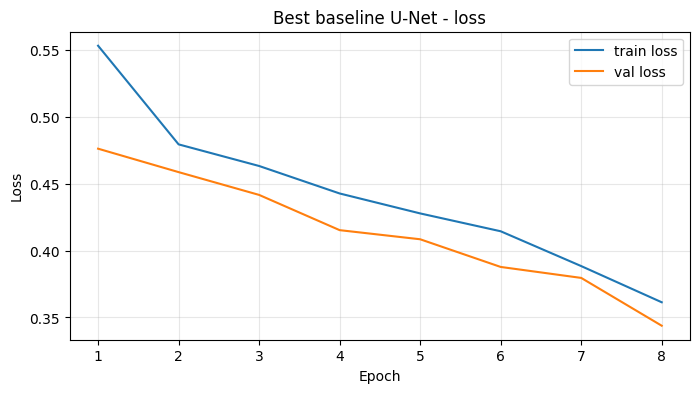

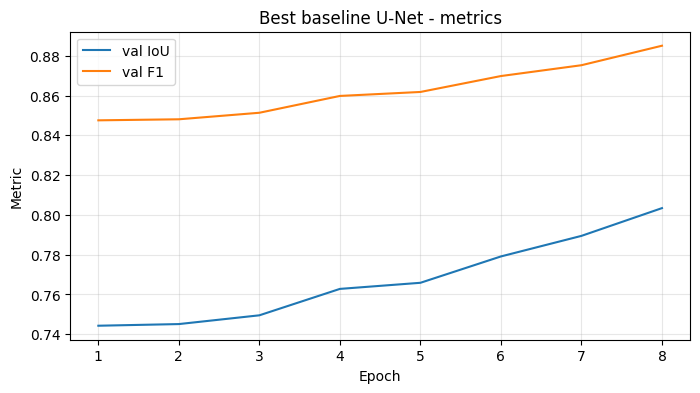

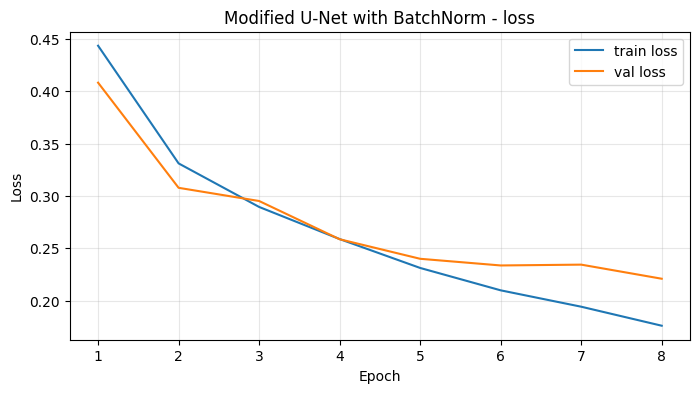

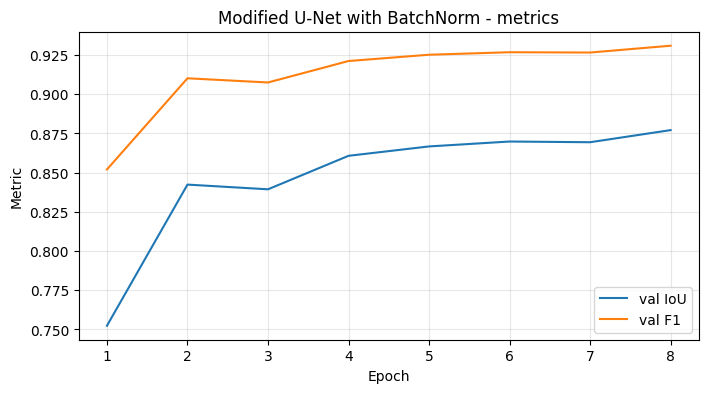

In [23]:
plot_history(best_baseline_result["history"], title="Best baseline U-Net")
plot_history(modified_result["history"], title="Modified U-Net with BatchNorm")

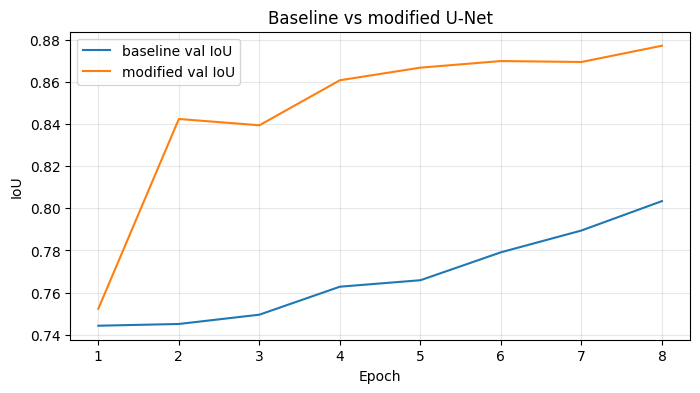

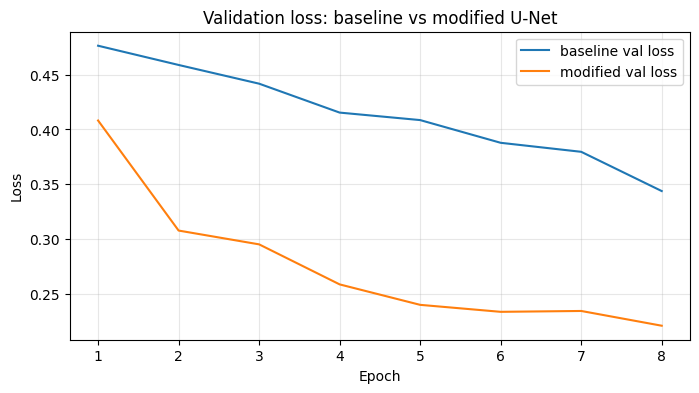

In [24]:
epochs = np.arange(1, len(best_baseline_result["history"]["val_iou"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, best_baseline_result["history"]["val_iou"], label="baseline val IoU")
plt.plot(epochs, modified_result["history"]["val_iou"], label="modified val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Baseline vs modified U-Net")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, best_baseline_result["history"]["val_loss"], label="baseline val loss")
plt.plot(epochs, modified_result["history"]["val_loss"], label="modified val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation loss: baseline vs modified U-Net")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

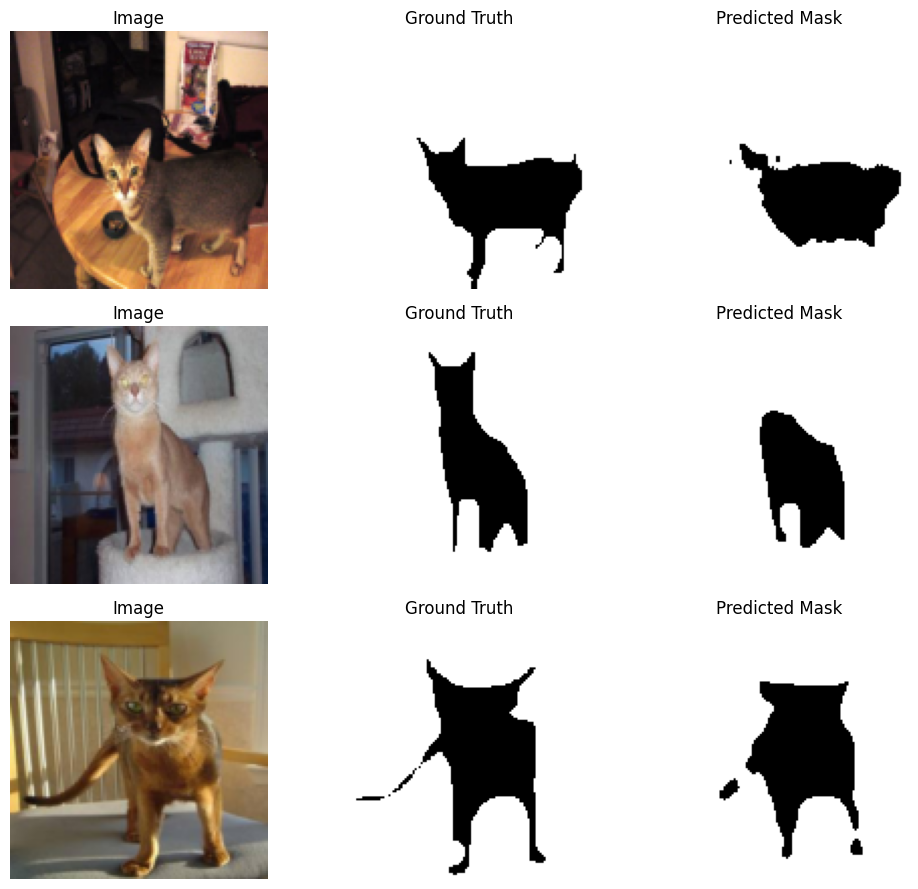

In [25]:
modified_result["trainer"].inference_and_plot_samples(n_samples=3)

In [26]:
# Выводы:
# 1) Перебор learning rate и batch size заметно влияет на сходимость U-Net
# 2) Слишком большой learning rate может давать нестабильное обучение, а слишком маленький - замедлять рост IoU
# 3) Batch size влияет на шумность градиентов: маленький batch может лучше обобщать, но сильнее шумит
# 4) Добавление BatchNorm делает оптимизацию стабильнее и часто ускоряет рост качества в первые эпохи
# 5) Итоговый выбор стоит делать по validation IoU/F1 и затем подтверждать на test